# BASEPROD Semantic Segmentation — RGB U-Net Baseline

This notebook builds an end-to-end, RGB-only semantic segmentation baseline. It never downloads or extracts the labeled archive. The verified archive is extracted outside the repository at `C:\\Users\\Anushka\\data\\BASEPROD_labeled`; the discovery cells check actual local pairs, dimensions, and mask IDs before enabling any training.

Dataset inspection and visualization require NumPy, Pillow, and Matplotlib. PyTorch is needed only for training, which is explicitly disabled by default with `RUN_TRAINING = False`. Run the notebook from the top to inspect the verified RGB/raw-mask pairs; no model training starts unless you first review the examples and enable the training flag.

## 1. Environment and imports

The configuration values below control the short baseline run. Required packages are checked and imported without installing or changing the project environment. `RUN_TRAINING` remains false until you explicitly enable it. This model does not require torchvision.

In [8]:
import importlib.util
import random
import sys
from pathlib import Path

NUM_EPOCHS = 5
BATCH_SIZE = 4
LEARNING_RATE = 1e-3
IMAGE_SIZE = (256, 256)  # (width, height); both dimensions should be divisible by 16.
RANDOM_SEED = 42
BASE_CHANNELS = 16
NUM_CLASSES = 8
RUN_TRAINING = True  # Run the configured five-epoch baseline training stage.
CLASS_NAMES = ["Void", "Compact", "Grass", "Bedrock", "Sandy", "Pebble", "Rock", "Vegetation"]
# RGB colors listed in the archive's BASEPROD_classes.txt class legend.
CLASS_COLORS = ["#000000", "#eab676", "#5b9f4a", "#8b8000", "#c04000", "#7393b3", "#e5e4e2", "#74d810"]
DATASET_ROOT_OVERRIDE = Path(r"C:\\Users\\Anushka\\data\\BASEPROD_labeled")

print(f"Python version: {sys.version.split()[0]}")
for package_name, module_name in [("PyTorch", "torch"), ("NumPy", "numpy"), ("Pillow", "PIL"), ("Matplotlib", "matplotlib")]:
    try:
        available = importlib.util.find_spec(module_name) is not None
    except (ImportError, ValueError):
        available = False
    print(f"{package_name}: {'available' if available else 'MISSING'}")

np = Image = plt = None
INSPECTION_READY = False
try:
    import numpy as np
    from PIL import Image
    import matplotlib.pyplot as plt
    from matplotlib.colors import ListedColormap
    from matplotlib.patches import Patch
except (ImportError, OSError) as exc:
    print(f"Dataset inspection/visualization imports failed: {type(exc).__name__}: {exc}")
else:
    INSPECTION_READY = True

# PyTorch is needed only for model training; dataset discovery and visualization remain usable without it.
torch = nn = F = DataLoader = Dataset = None
DEPENDENCIES_READY = False
CUDA_AVAILABLE = False
DEVICE = None
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import DataLoader, Dataset
except (ImportError, OSError, RuntimeError) as exc:
    print(f"Training imports unavailable: {type(exc).__name__}: {exc}")
else:
    DEPENDENCIES_READY = INSPECTION_READY
    print(f"PyTorch version: {torch.__version__}")
    CUDA_AVAILABLE = torch.cuda.is_available()
    DEVICE = torch.device("cuda" if CUDA_AVAILABLE else "cpu")
    print(f"CUDA available: {CUDA_AVAILABLE}")
    print(f"Selected device: {DEVICE}")

if not DEPENDENCIES_READY:
    print("Training is disabled because PyTorch is unavailable; no packages will be installed by this notebook.")
if not INSPECTION_READY:
    print("Dataset image inspection requires NumPy, Pillow, and Matplotlib; install them in the selected environment before rerunning.")

random.seed(RANDOM_SEED)
if INSPECTION_READY:
    np.random.seed(RANDOM_SEED)
if DEPENDENCIES_READY:
    torch.manual_seed(RANDOM_SEED)
    if CUDA_AVAILABLE:
        torch.cuda.manual_seed_all(RANDOM_SEED)


Python version: 3.12.7
PyTorch: available
NumPy: available
Pillow: available
Matplotlib: available
PyTorch version: 2.14.1+cpu
CUDA available: False
Selected device: cpu


## 2. Dataset discovery and pairing verification

This dataset was extracted outside the repository from the verified archive. The first baseline uses only `BASEPROD/ORIGINAL/COLOR_IMGS` and `BASEPROD/ORIGINAL/MASK_RAWS`; the archive also contains `FRAMED` variants with the same timestamp keys, so the two variants are not pooled. RGB files are paired only with a raw mask whose basename is the identical timestamp plus `_mask`. Every pair, image size, single-channel mask, and mask class ID is checked before visualization or training.

In [9]:
import os
import re
import zipfile

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((parent for parent in (cwd, *cwd.parents) if (parent / "notebooks").is_dir()), cwd)
home = Path.home()
search_roots = [PROJECT_ROOT / "datasets", PROJECT_ROOT / "data", PROJECT_ROOT / "BASEPROD_labeled", home / "Downloads" / "BASEPROD_labeled", home / "data" / "BASEPROD_labeled"]
if DATASET_ROOT_OVERRIDE is not None:
    override_path = Path(DATASET_ROOT_OVERRIDE).expanduser().resolve()
    search_roots = [override_path / "BASEPROD" / "ORIGINAL" / "COLOR_IMGS", override_path / "BASEPROD" / "ORIGINAL" / "MASK_RAWS"]
else:
    override_path = None

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}
excluded_parts = {".git", ".venv", ".venv-1", "__pycache__", ".cache", "outputs"}
image_files = set()
found_archives = set()
if override_path is not None:
    archive_candidate = override_path.with_suffix(".zip")
    if archive_candidate.is_file():
        found_archives.add(archive_candidate)
existing_roots = [root for root in search_roots if root.exists()]
for root in existing_roots:
    if root.is_file() and root.suffix.lower() == ".zip":
        found_archives.add(root)
        continue
    if not root.is_dir():
        continue
    for current, directories, filenames in os.walk(root):
        directories[:] = [name for name in directories if name.lower() not in excluded_parts]
        current_path = Path(current)
        for filename in filenames:
            path = current_path / filename
            if path.suffix.lower() in IMAGE_EXTENSIONS:
                image_files.add(path.resolve())
            elif path.suffix.lower() == ".zip" and ("baseprod" in filename.lower() or "label" in filename.lower()):
                found_archives.add(path.resolve())

print(f"Project root: {PROJECT_ROOT}")
print(f"Selected dataset variant: ORIGINAL (RGB-only baseline); extracted root: {override_path}")
print("Local locations searched:")
for root in search_roots:
    print(f"  {root} ({'exists' if root.exists() else 'not found'})")
print(f"Image files found: {len(image_files)}")
print(f"Labeled archive files found: {len(found_archives)}")
for archive_path in sorted(found_archives):
    print(f"Archive: {archive_path}")
    try:
        with zipfile.ZipFile(archive_path) as archive:
            members = [item.filename for item in archive.infolist() if not item.is_dir()]
            print(f"  Entries: {len(members)}; example paths:")
            for name in members[:15]:
                print(f"    {name}")
            for group in ("BASEPROD/ORIGINAL/DEPTH_IMGS/", "BASEPROD/FRAMED/DEPTH_IMGS/", "BASEPROD/COMMON_THERMAL_IMGS/"):
                count = sum(name.startswith(group) and name.lower().endswith(".csv") for name in members)
                print(f"  {group}: {count} CSV files (not used by this RGB-only baseline)")
    except (OSError, zipfile.BadZipFile) as exc:
        print(f"  Archive could not be inspected: {type(exc).__name__}: {exc}")

DATASET_READY = False
SAMPLES = []
DEPTH_FILES = []
THERMAL_FILES = []
MASK_IDS_FOUND = set()
IMAGE_SIZES_FOUND = set()
pairing_failures = []

def role_tokens(path):
    return set(re.findall(r"[a-z0-9]+", " ".join(path.parts).lower()))

RGB_MARKERS = {"rgb", "color", "colour", "visible"}
MASK_MARKERS = {"mask", "masks", "seg", "segmentation", "semantic", "label", "labels", "gt", "groundtruth", "annotation", "annotations"}
DEPTH_MARKERS = {"depth", "range"}
THERMAL_MARKERS = {"thermal", "infrared", "infra"}
ROLE_MARKERS = RGB_MARKERS | MASK_MARKERS | DEPTH_MARKERS | THERMAL_MARKERS | {"image", "images"}

def image_role(path):
    tokens = role_tokens(path)
    roles = []
    if tokens & RGB_MARKERS:
        roles.append("rgb")
    if tokens & MASK_MARKERS:
        roles.append("mask")
    if tokens & DEPTH_MARKERS:
        roles.append("depth")
    if tokens & THERMAL_MARKERS:
        roles.append("thermal")
    return roles

def sample_key(path):
    tokens = re.findall(r"[a-z0-9]+", path.stem.lower())
    key_tokens = [token for token in tokens if token not in ROLE_MARKERS]
    return "_".join(key_tokens)

if not INSPECTION_READY:
    print("\nDataset verification skipped because NumPy, Pillow, or Matplotlib could not be imported.")
elif not image_files and not found_archives:
    print("\nLabeled BASEPROD dataset not found locally.")
    print("Place the labeled dataset in one of the searched folders, or set DATASET_ROOT_OVERRIDE, then rerun this cell.")
    print("No archive was downloaded or extracted.")
elif not image_files and found_archives:
    print("\nLabeled BASEPROD data appears to be present only in an archive.")
    print("The archive structure was listed above. Extract it manually to a local folder; this notebook will not unpack it.")
else:
    role_map = {"rgb": {}, "mask": {}}
    for path in sorted(image_files):
        roles = image_role(path)
        if len(roles) > 1:
            pairing_failures.append(f"Ambiguous modality markers {roles}: {path}")
        elif roles and roles[0] in role_map:
            key = sample_key(path)
            if not key:
                pairing_failures.append(f"No sample identity remains after reading role markers: {path}")
            else:
                role_map[roles[0]].setdefault(key, []).append(path)
        elif roles and roles[0] == "depth":
            DEPTH_FILES.append(path)
        elif roles and roles[0] == "thermal":
            THERMAL_FILES.append(path)
        else:
            print(f"Unclassified image file (not used): {path}")

    print(f"Role-marked RGB candidates: {sum(map(len, role_map['rgb'].values()))}")
    print(f"Role-marked mask candidates: {sum(map(len, role_map['mask'].values()))}")
    print(f"Depth images identified: {len(DEPTH_FILES)}; thermal images identified: {len(THERMAL_FILES)}")
    print("Pairing rule: each ORIGINAL/COLOR_IMGS/<timestamp>.png must have exactly one ORIGINAL/MASK_RAWS/<timestamp>_mask.png.")
    for key in sorted(set(role_map["rgb"]) & set(role_map["mask"])):
        rgbs, masks = role_map["rgb"][key], role_map["mask"][key]
        if len(rgbs) != 1 or len(masks) != 1:
            pairing_failures.append(f"Sample key {key!r} is not unique: {len(rgbs)} RGB files, {len(masks)} masks")
            continue
        rgb_path, mask_path = rgbs[0], masks[0]
        try:
            if mask_path.name != f"{rgb_path.stem}_mask.png":
                pairing_failures.append(f"Mask filename does not match the verified timestamp suffix for {rgb_path.name}: {mask_path.name}")
                continue
            with Image.open(rgb_path) as rgb_image, Image.open(mask_path) as mask_image:
                rgb_size, mask_size = rgb_image.size, mask_image.size
                rgb_mode, mask_mode = rgb_image.mode, mask_image.mode
                mask_array = np.asarray(mask_image)
            IMAGE_SIZES_FOUND.add(rgb_size)
            if rgb_mode != "RGB":
                pairing_failures.append(f"RGB candidate is not RGB mode (mode {rgb_mode}): {rgb_path}")
                continue
            if mask_mode != "L":
                pairing_failures.append(f"Raw mask is not single-channel L mode (mode {mask_mode}): {mask_path}")
                continue
            if len(mask_array.shape) != 2:
                pairing_failures.append(f"Mask is not single-channel (shape {mask_array.shape}): {mask_path}")
                continue
            if rgb_size != mask_size:
                pairing_failures.append(f"Dimension mismatch for key {key!r}: RGB {rgb_size}, mask {mask_size}")
                continue
            if rgb_size != (1280, 720):
                pairing_failures.append(f"Unexpected image/mask resolution for key {key!r}: {rgb_size}; expected (1280, 720)")
                continue
            mask_ids = set(int(value) for value in np.unique(mask_array))
            MASK_IDS_FOUND.update(mask_ids)
            rel_parts = set(rgb_path.relative_to(PROJECT_ROOT).parts) if rgb_path.is_relative_to(PROJECT_ROOT) else set(rgb_path.parts)
            split_names = {part.lower() for part in rel_parts}
            split_hint = "train" if split_names & {"train", "training"} else "val" if split_names & {"val", "valid", "validation"} else "test" if "test" in split_names else None
            SAMPLES.append({"key": key, "rgb_path": rgb_path, "mask_path": mask_path, "size": rgb_size, "mask_ids": mask_ids, "split_hint": split_hint})
        except (OSError, ValueError) as exc:
            pairing_failures.append(f"Could not read candidate pair {key!r}: {type(exc).__name__}: {exc}")

    unmatched_rgb = sorted(set(role_map["rgb"]) - set(role_map["mask"]))
    unmatched_masks = sorted(set(role_map["mask"]) - set(role_map["rgb"]))
    if unmatched_rgb:
        pairing_failures.append(f"RGB sample keys with no mask: {unmatched_rgb[:20]}")
    if unmatched_masks:
        pairing_failures.append(f"Mask sample keys with no RGB: {unmatched_masks[:20]}")

    print(f"\nVerified unique dimension-matched pairs: {len(SAMPLES)}")
    print(f"Verified image dimensions: {sorted(IMAGE_SIZES_FOUND)}")
    for sample in SAMPLES[:10]:
        print(f"  {sample['key']}: RGB={sample['rgb_path'].name}, mask={sample['mask_path'].name}, size={sample['size']}, IDs={sorted(sample['mask_ids'])}")
    print(f"Unique mask IDs observed across paired masks: {sorted(MASK_IDS_FOUND)}")
    expected_ids = set(range(NUM_CLASSES))
    if MASK_IDS_FOUND and MASK_IDS_FOUND != expected_ids:
        pairing_failures.append(f"Mask IDs must be exactly 0-7; observed {sorted(MASK_IDS_FOUND)}")
    if not SAMPLES:
        pairing_failures.append("No unique RGB/mask pairs were verified.")
    if pairing_failures:
        print("\nSTOP: dataset validation failed. Resolve each item before training:")
        for failure in pairing_failures:
            print(f"  - {failure}")
    else:
        DATASET_READY = True
        print("\nDataset pairing and mask-value checks passed. No test split will be used for training or validation.")

PIPELINE_READY = DEPENDENCIES_READY and DATASET_READY


Project root: C:\Users\Anushka\UA-MTSeg-Rover-Navigation\UA-MTSeg-Rover-Navigation
Selected dataset variant: ORIGINAL (RGB-only baseline); extracted root: C:\Users\Anushka\data\BASEPROD_labeled
Local locations searched:
  C:\Users\Anushka\data\BASEPROD_labeled\BASEPROD\ORIGINAL\COLOR_IMGS (exists)
  C:\Users\Anushka\data\BASEPROD_labeled\BASEPROD\ORIGINAL\MASK_RAWS (exists)
Image files found: 1900
Labeled archive files found: 1
Archive: C:\Users\Anushka\data\BASEPROD_labeled.zip
  Entries: 8551; example paths:
    BASEPROD/COMMON_THERMAL_IMGS/168986961442400000t.csv
    BASEPROD/COMMON_THERMAL_IMGS/168986961982400000t.csv
    BASEPROD/COMMON_THERMAL_IMGS/168986962142400000t.csv
    BASEPROD/COMMON_THERMAL_IMGS/168986962402400000t.csv
    BASEPROD/COMMON_THERMAL_IMGS/168986962662500000t.csv
    BASEPROD/COMMON_THERMAL_IMGS/168986962782400000t.csv
    BASEPROD/COMMON_THERMAL_IMGS/168986966262400000t.csv
    BASEPROD/COMMON_THERMAL_IMGS/168986966402400000t.csv
    BASEPROD/COMMON_THERMAL_

## 3. Visual verification

Before training, inspect several verified pairs: RGB, raw class-ID mask, and overlay. The legend always lists all eight requested classes, and the printed unique IDs let you check the labels visually. This step is skipped unless local pair and class-ID checks succeeded.

168986961442400000: mask IDs [0, 1, 2, 5, 6, 7]


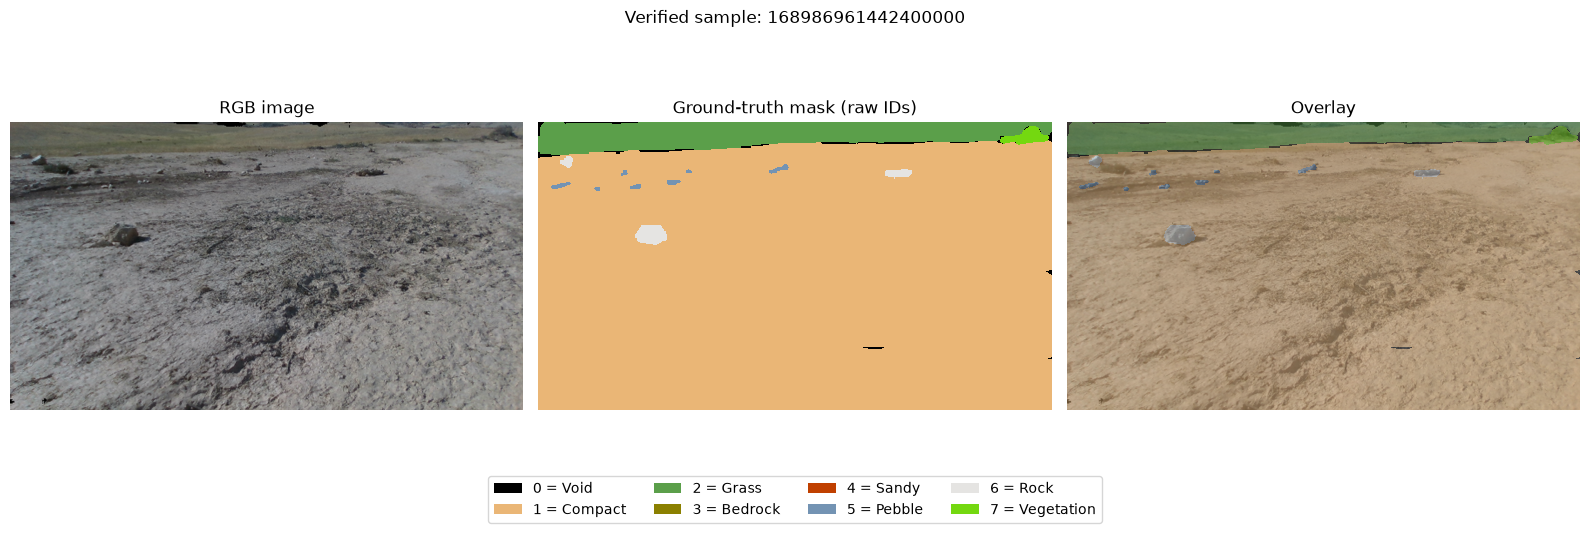

168986961982400000: mask IDs [0, 1, 2, 5, 6]


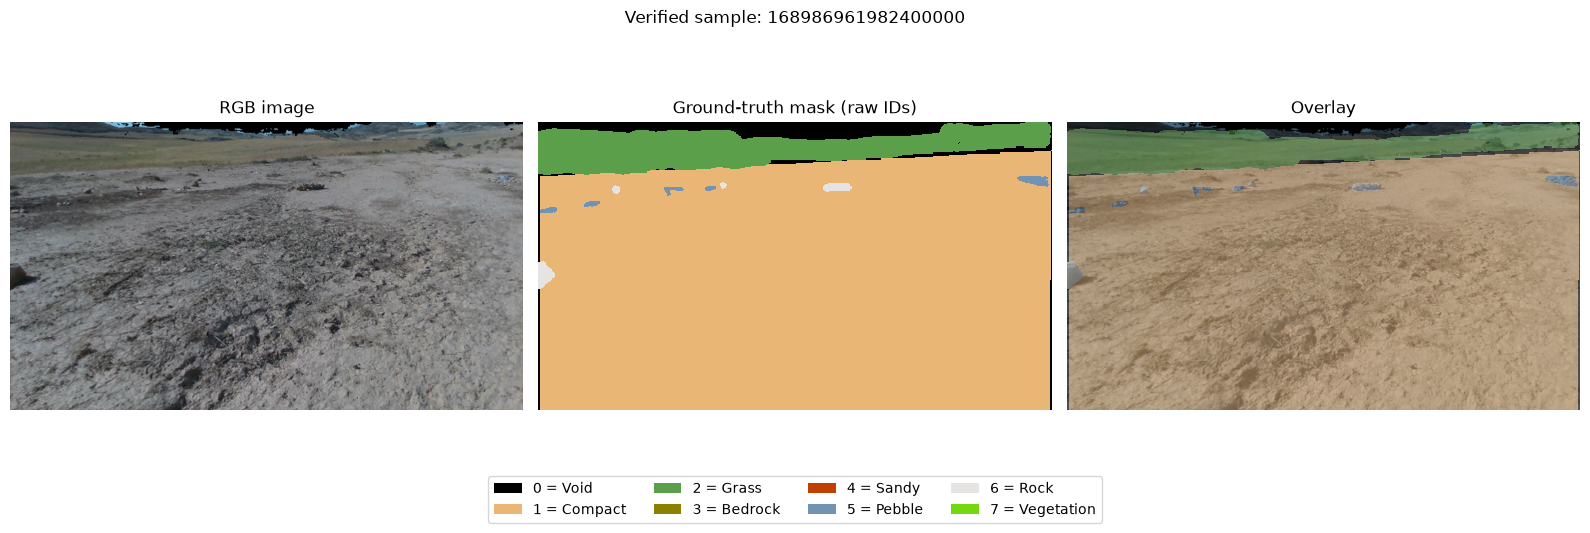

168986962142400000: mask IDs [0, 1, 2, 6]


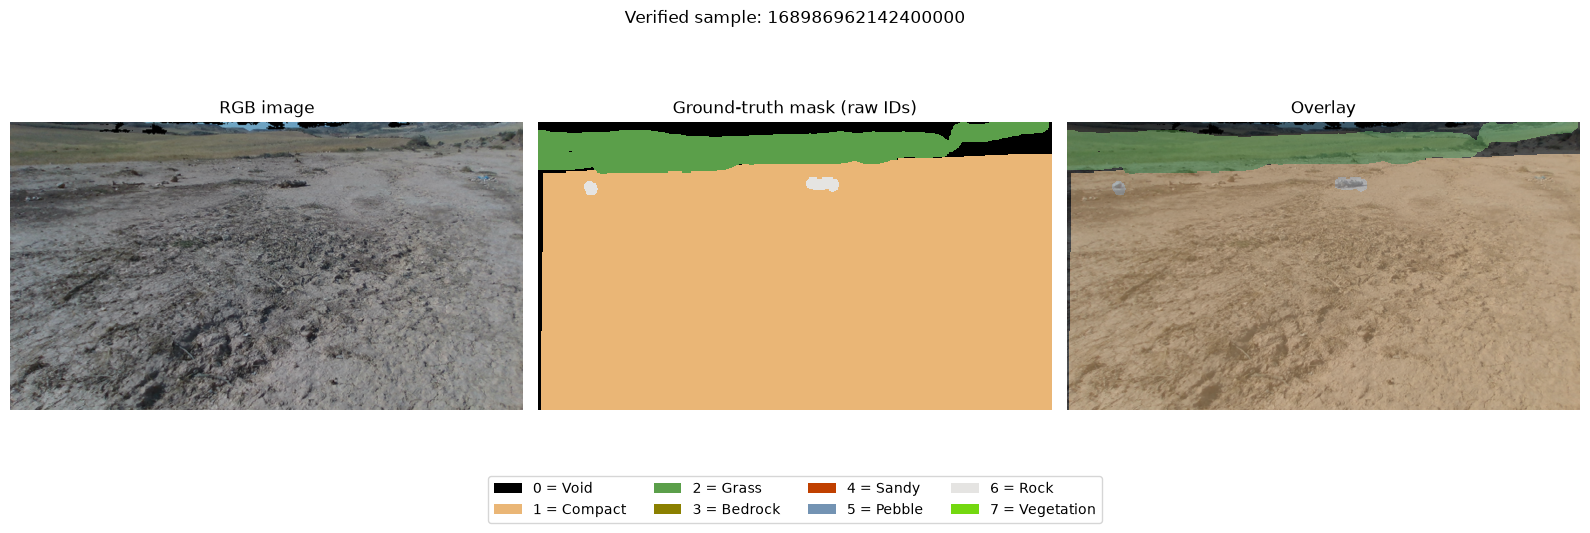

168986962402400000: mask IDs [0, 1, 2, 5, 6, 7]


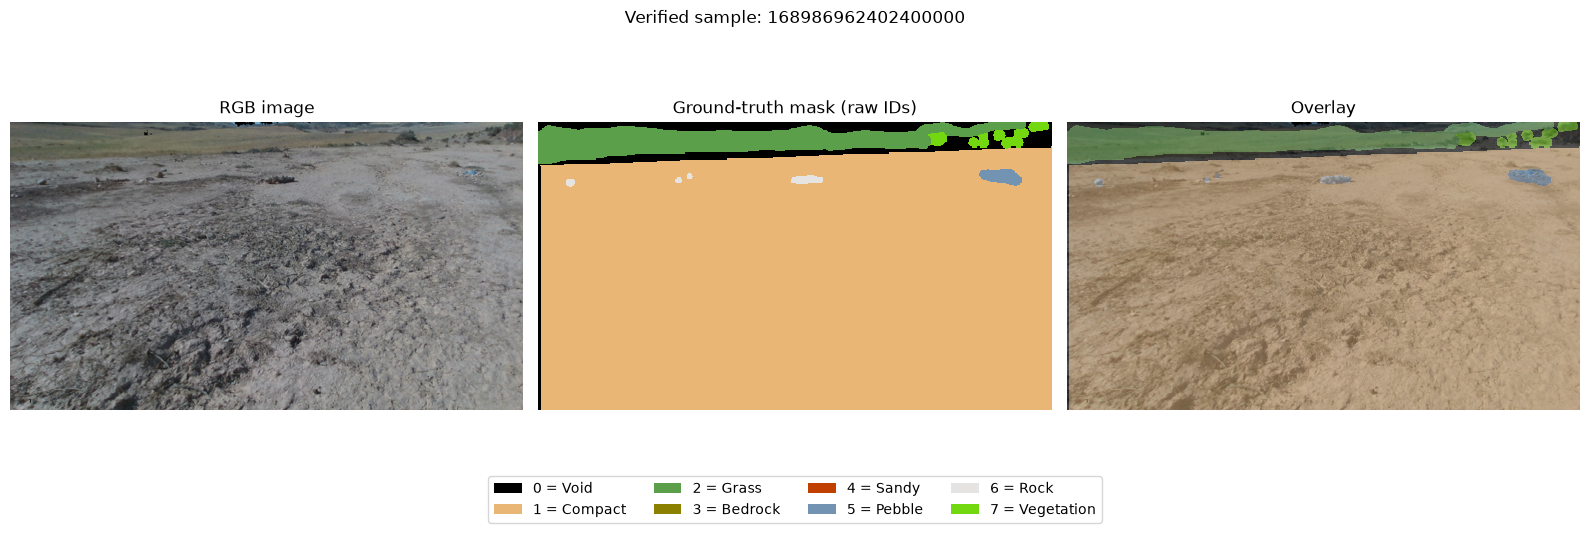

In [18]:
if DATASET_READY and INSPECTION_READY:
    cmap = ListedColormap(CLASS_COLORS)
    legend_items = [Patch(facecolor=CLASS_COLORS[i], label=f"{i} = {CLASS_NAMES[i]}") for i in range(NUM_CLASSES)]
    for sample in SAMPLES[:4]:
        with Image.open(sample["rgb_path"]) as image:
            rgb = np.asarray(image.convert("RGB"))
        with Image.open(sample["mask_path"]) as image:
            mask = np.asarray(image)
        print(f"{sample['key']}: mask IDs {sorted(int(v) for v in np.unique(mask))}")
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        axes[0].imshow(rgb); axes[0].set_title("RGB image")
        axes[1].imshow(mask, cmap=cmap, vmin=-0.5, vmax=7.5, interpolation="nearest"); axes[1].set_title("Ground-truth mask (raw IDs)")
        axes[2].imshow(rgb); axes[2].imshow(mask, cmap=cmap, vmin=-0.5, vmax=7.5, alpha=0.45, interpolation="nearest"); axes[2].set_title("Overlay")
        for axis in axes: axis.axis("off")
        fig.legend(handles=legend_items, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.06))
        fig.suptitle(f"Verified sample: {sample['key']}")
        plt.tight_layout(); plt.show()
else:
    print("Visual verification skipped: a valid local dataset with verified pairs and IDs 0-7 is required.")


## 4. PyTorch Dataset

Each item loads the paired RGB image and single-channel mask. RGB is resized with bilinear interpolation; masks use nearest-neighbor interpolation so class IDs remain integers. Masks are returned as `long` tensors for `CrossEntropyLoss`.

In [10]:
if PIPELINE_READY:
    class BaseprodSegmentationDataset(Dataset):
        def __init__(self, samples, image_size):
            self.samples = list(samples)
            self.image_size = tuple(image_size)

        def __len__(self):
            return len(self.samples)

        def __getitem__(self, index):
            sample = self.samples[index]
            with Image.open(sample["rgb_path"]) as image:
                rgb = image.convert("RGB").resize(self.image_size, resample=Image.Resampling.BILINEAR)
                image_array = np.asarray(rgb, dtype=np.float32) / 255.0
            with Image.open(sample["mask_path"]) as image:
                if len(np.asarray(image).shape) != 2:
                    raise ValueError(f"Expected a single-channel mask: {sample['mask_path']}")
                mask = image.resize(self.image_size, resample=Image.Resampling.NEAREST)
                mask_array = np.asarray(mask, dtype=np.int64)
            if not set(int(v) for v in np.unique(mask_array)).issubset(set(range(NUM_CLASSES))):
                raise ValueError(f"Unexpected class IDs in {sample['mask_path']}: {np.unique(mask_array).tolist()}")
            image_tensor = torch.from_numpy(np.ascontiguousarray(image_array.transpose(2, 0, 1)))
            mask_tensor = torch.from_numpy(np.ascontiguousarray(mask_array)).long()
            return image_tensor, mask_tensor

    print(f"Dataset class ready for {len(SAMPLES)} verified RGB/mask pairs at {IMAGE_SIZE} pixels.")
else:
    print("Dataset class definition skipped at runtime; its complete implementation is above and activates after validation passes.")


Dataset class ready for 950 verified RGB/mask pairs at (256, 256) pixels.


## 5. Train/validation split

Use path-provided train and validation folders only when both are found. A test folder is never used. If there is no complete official train/validation pair, create a reproducible 80/20 split from eligible non-test samples using `RANDOM_SEED`.

In [11]:
if PIPELINE_READY:
    official_train = [sample for sample in SAMPLES if sample["split_hint"] == "train"]
    official_val = [sample for sample in SAMPLES if sample["split_hint"] == "val"]
    official_test = [sample for sample in SAMPLES if sample["split_hint"] == "test"]
    unassigned = [sample for sample in SAMPLES if sample["split_hint"] is None]
    if official_train and official_val and not unassigned:
        train_samples, val_samples = official_train, official_val
        SPLIT_DESCRIPTION = "existing train/validation folders"
        print("Using verified existing train and validation folders; test samples are excluded.")
        if official_test:
            print(f"Excluded test samples (not used): {len(official_test)}")
    else:
        eligible = [sample for sample in SAMPLES if sample["split_hint"] != "test"]
        if official_test:
            print(f"Test samples excluded from all work: {len(official_test)}")
        rng = random.Random(RANDOM_SEED)
        shuffled = list(eligible)
        rng.shuffle(shuffled)
        if len(shuffled) < 2:
            raise ValueError("At least two non-test verified pairs are required for train/validation.")
        val_count = max(1, int(round(0.2 * len(shuffled))))
        val_count = min(val_count, len(shuffled) - 1)
        val_samples = shuffled[:val_count]
        train_samples = shuffled[val_count:]
        SPLIT_DESCRIPTION = f"reproducible random 80/20 split (seed={RANDOM_SEED}) of non-test samples"
        if official_train and not official_val:
            SPLIT_DESCRIPTION += "; no validation folder existed, so only the discovered train samples were split"
        print(f"Using {SPLIT_DESCRIPTION}.")
    if not train_samples or not val_samples:
        raise ValueError("Train and validation partitions must both contain at least one sample.")
    print(f"Training samples: {len(train_samples)}")
    print(f"Validation samples: {len(val_samples)}")
else:
    train_samples, val_samples = [], []
    SPLIT_DESCRIPTION = "not created; dataset or dependencies are unavailable"
    print("Train/validation split not created because verified data and dependencies are required.")


Using reproducible random 80/20 split (seed=42) of non-test samples.
Training samples: 760
Validation samples: 190


## 6. DataLoaders

The loaders batch the resized image tensors and integer masks. The training loader shuffles only the training partition; validation remains in a stable order.

In [12]:
if PIPELINE_READY:
    train_dataset = BaseprodSegmentationDataset(train_samples, IMAGE_SIZE)
    val_dataset = BaseprodSegmentationDataset(val_samples, IMAGE_SIZE)
    loader_workers = 0  # Conservative default for notebook kernels and Windows.
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=loader_workers, pin_memory=(DEVICE.type == "cuda"))
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=loader_workers, pin_memory=(DEVICE.type == "cuda"))
    first_images, first_masks = next(iter(train_loader))
    print(f"Training batches: {len(train_loader)}; validation batches: {len(val_loader)}")
    print(f"Image batch shape: {tuple(first_images.shape)}; mask batch shape: {tuple(first_masks.shape)}")
    del first_images, first_masks
else:
    print("DataLoaders not created: verified data and PyTorch are required.")


Training batches: 190; validation batches: 48
Image batch shape: (4, 3, 256, 256); mask batch shape: (4, 256, 256)


## 7. U-Net model

This scratch-built U-Net uses encoder blocks, max pooling, transposed-convolution upsampling, skip connections, and a 1×1 output convolution. With RGB input and eight output channels, the logits have shape `[B, 8, H, W]`. No pretrained weights are used.

In [13]:
if PIPELINE_READY:
    class ConvBlock(nn.Module):
        def __init__(self, in_channels, out_channels):
            super().__init__()
            self.layers = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            )

        def forward(self, x):
            return self.layers(x)

    class UNet(nn.Module):
        def __init__(self, in_channels=3, num_classes=NUM_CLASSES, base_channels=BASE_CHANNELS):
            super().__init__()
            widths = [base_channels, base_channels * 2, base_channels * 4, base_channels * 8]
            self.enc1 = ConvBlock(in_channels, widths[0])
            self.enc2 = ConvBlock(widths[0], widths[1])
            self.enc3 = ConvBlock(widths[1], widths[2])
            self.enc4 = ConvBlock(widths[2], widths[3])
            self.pool = nn.MaxPool2d(2)
            self.bottleneck = ConvBlock(widths[3], widths[3] * 2)
            self.up4 = nn.ConvTranspose2d(widths[3] * 2, widths[3], kernel_size=2, stride=2)
            self.dec4 = ConvBlock(widths[3] * 2, widths[3])
            self.up3 = nn.ConvTranspose2d(widths[3], widths[2], kernel_size=2, stride=2)
            self.dec3 = ConvBlock(widths[2] * 2, widths[2])
            self.up2 = nn.ConvTranspose2d(widths[2], widths[1], kernel_size=2, stride=2)
            self.dec2 = ConvBlock(widths[1] * 2, widths[1])
            self.up1 = nn.ConvTranspose2d(widths[1], widths[0], kernel_size=2, stride=2)
            self.dec1 = ConvBlock(widths[0] * 2, widths[0])
            self.classifier = nn.Conv2d(widths[0], num_classes, kernel_size=1)

        def forward(self, x):
            e1 = self.enc1(x)
            e2 = self.enc2(self.pool(e1))
            e3 = self.enc3(self.pool(e2))
            e4 = self.enc4(self.pool(e3))
            b = self.bottleneck(self.pool(e4))
            d4 = self.dec4(torch.cat((self.up4(b), e4), dim=1))
            d3 = self.dec3(torch.cat((self.up3(d4), e3), dim=1))
            d2 = self.dec2(torch.cat((self.up2(d3), e2), dim=1))
            d1 = self.dec1(torch.cat((self.up1(d2), e1), dim=1))
            return self.classifier(d1)

    model = UNet().to(DEVICE)
    with torch.no_grad():
        test_shape = model(torch.zeros(1, 3, IMAGE_SIZE[1], IMAGE_SIZE[0], device=DEVICE)).shape
    print(f"Model: U-Net (from scratch); output shape: {tuple(test_shape)}")
    assert test_shape == (1, NUM_CLASSES, IMAGE_SIZE[1], IMAGE_SIZE[0])
else:
    print("U-Net definition is included above; instantiate it after dataset and dependency checks pass.")


Model: U-Net (from scratch); output shape: (1, 8, 256, 256)


## 8. Loss function

`CrossEntropyLoss` is suitable because every pixel belongs to one mutually exclusive class. It consumes raw per-class logits and an integer class-ID target map; do not apply softmax before this loss.

In [14]:
if PIPELINE_READY:
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    print(f"Loss: {criterion}; optimizer: Adam (learning rate={LEARNING_RATE})")
else:
    print("Loss and optimizer will be initialized once the model can be constructed.")


Loss: CrossEntropyLoss(); optimizer: Adam (learning rate=0.001)


## 9. Segmentation metrics

A confusion matrix gives pixel accuracy and class-wise IoU. A class with no target or predicted pixels has an undefined IoU (`NaN`) and is excluded from the mean, rather than causing division by zero.

In [15]:
if PIPELINE_READY:
    def update_confusion_matrix(confusion, logits, targets):
        predictions = logits.argmax(dim=1).reshape(-1)
        targets = targets.reshape(-1)
        valid = (targets >= 0) & (targets < NUM_CLASSES)
        encoded = NUM_CLASSES * targets[valid].long() + predictions[valid].long()
        confusion += torch.bincount(encoded, minlength=NUM_CLASSES ** 2).reshape(NUM_CLASSES, NUM_CLASSES)
        return confusion

    def metrics_from_confusion(confusion):
        matrix = confusion.to(torch.float64)
        true_positive = matrix.diag()
        union = matrix.sum(dim=0) + matrix.sum(dim=1) - true_positive
        iou = torch.full((NUM_CLASSES,), float("nan"), dtype=torch.float64, device=matrix.device)
        present = union > 0
        iou[present] = true_positive[present] / union[present]
        total = matrix.sum()
        accuracy = (true_positive.sum() / total).item() if total > 0 else float("nan")
        mean_iou = torch.nanmean(iou).item() if present.any() else float("nan")
        return accuracy, mean_iou, iou.cpu().tolist()

    def print_class_iou_table(class_ious):
        print(f"{'ID':>2}  {'Class':<12}  {'IoU':>10}")
        print("-" * 28)
        for class_id, (name, value) in enumerate(zip(CLASS_NAMES, class_ious)):
            formatted = "absent" if np.isnan(value) else f"{value:.4f}"
            print(f"{class_id:>2}  {name:<12}  {formatted:>10}")
else:
    print("Metric functions are defined in this cell and activate once dependencies and data are ready.")


## 10. Short baseline training

The defaults are only five epochs, a 256×256 input, and batch size four. Training is off by default; first inspect the verified samples, then set `RUN_TRAINING = True` in Section 1 when ready. Validation loss and metrics are accumulated over all validation pixels each epoch.

In [19]:
history = []
best_val_miou = float("-inf")
best_state = None
best_metrics = None

if PIPELINE_READY and RUN_TRAINING:
    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        train_loss_sum = 0.0
        train_pixels = 0
        for images, masks in train_loader:
            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()
            pixels = masks.numel()
            train_loss_sum += loss.item() * pixels
            train_pixels += pixels
        train_loss = train_loss_sum / max(train_pixels, 1)

        model.eval()
        val_loss_sum = 0.0
        val_pixels = 0
        confusion = torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.int64, device=DEVICE)
        with torch.inference_mode():
            for images, masks in val_loader:
                images = images.to(DEVICE, non_blocking=True)
                masks = masks.to(DEVICE, non_blocking=True)
                logits = model(images)
                loss = criterion(logits, masks)
                pixels = masks.numel()
                val_loss_sum += loss.item() * pixels
                val_pixels += pixels
                update_confusion_matrix(confusion, logits, masks)
        val_loss = val_loss_sum / max(val_pixels, 1)
        pixel_accuracy, val_miou, per_class_iou = metrics_from_confusion(confusion)
        row = {"epoch": epoch, "train_loss": train_loss, "validation_loss": val_loss, "pixel_accuracy": pixel_accuracy, "mean_iou": val_miou}
        history.append(row)
        print(f"Epoch {epoch}/{NUM_EPOCHS} | train loss {train_loss:.4f} | val loss {val_loss:.4f} | pixel accuracy {pixel_accuracy:.4f} | mIoU {val_miou:.4f}")
        if np.isfinite(val_miou) and val_miou > best_val_miou:
            best_val_miou = val_miou
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            best_metrics = {"pixel_accuracy": pixel_accuracy, "mean_iou": val_miou, "per_class_iou": per_class_iou}
    if best_state is None:
        raise RuntimeError("Training completed without a finite validation mIoU; no best checkpoint is available.")
    model.load_state_dict(best_state)
    print(f"Best validation mIoU: {best_val_miou:.4f}")
else:
    print("Training not run: set RUN_TRAINING = True only after reviewing the verified samples; labeled data and working PyTorch are also required.")


Training not run: set RUN_TRAINING = True only after reviewing the verified samples; labeled data and working PyTorch are also required.


## 11. Save the best model

The checkpoint is written under the untracked-style output folder `outputs/segmentation/` only after a successful training run. No model file is created when training is skipped.

In [26]:
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "segmentation"
BEST_MODEL_PATH = OUTPUT_DIR / "best_unet_rgb.pt"
if PIPELINE_READY and best_state is not None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    torch.save({"model_name": "U-Net RGB baseline", "model_state_dict": best_state, "class_names": CLASS_NAMES, "image_size": IMAGE_SIZE, "num_classes": NUM_CLASSES, "best_validation_miou": best_val_miou, "random_seed": RANDOM_SEED}, BEST_MODEL_PATH)
    print(f"Best model saved to: {BEST_MODEL_PATH}")
else:
    print("Model checkpoint not saved because no trained best model is available.")


Model checkpoint not saved because no trained best model is available.


## 12. Prediction visualization

For a few validation images, compare RGB, ground truth, model prediction, and prediction overlay using the same class colors and legend.

In [27]:
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "segmentation"
BEST_MODEL_PATH = OUTPUT_DIR / "best_unet_rgb.pt"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
prediction_figures = []
cmap = ListedColormap(CLASS_COLORS)
legend_items = [Patch(facecolor=CLASS_COLORS[i], label=f"{i} = {CLASS_NAMES[i]}") for i in range(NUM_CLASSES)]
if PIPELINE_READY and BEST_MODEL_PATH.is_file():
    checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=True)
    model.load_state_dict(checkpoint["model_state_dict"])
    best_state = checkpoint["model_state_dict"]
    print(f"Loaded saved best model: {BEST_MODEL_PATH}")
    model.eval()
    for sample_index in range(min(4, len(val_dataset))):
        image_tensor, target_tensor = val_dataset[sample_index]
        with torch.inference_mode():
            prediction = model(image_tensor.unsqueeze(0).to(DEVICE)).argmax(dim=1)[0].cpu().numpy()
        rgb = np.asarray(Image.open(val_samples[sample_index]["rgb_path"]).convert("RGB"))
        target = target_tensor.numpy()
        fig, axes = plt.subplots(1, 4, figsize=(19, 5))
        axes[0].imshow(rgb); axes[0].set_title("RGB")
        axes[1].imshow(target, cmap=cmap, vmin=-0.5, vmax=7.5, interpolation="nearest"); axes[1].set_title("Ground truth")
        axes[2].imshow(prediction, cmap=cmap, vmin=-0.5, vmax=7.5, interpolation="nearest"); axes[2].set_title("Prediction")
        axes[3].imshow(rgb); axes[3].imshow(prediction, cmap=cmap, vmin=-0.5, vmax=7.5, alpha=0.45, interpolation="nearest"); axes[3].set_title("Prediction overlay")
        for axis in axes: axis.axis("off")
        fig.legend(handles=legend_items, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.06))
        fig.suptitle(f"Validation prediction: {val_samples[sample_index]['key']}")
        plt.tight_layout()
        plt.show()
        prediction_figures.append((fig, val_samples[sample_index]["key"]))
else:
    print("Prediction visualization skipped: a trained model and validation dataset are required.")


Prediction visualization skipped: a trained model and validation dataset are required.


## 13. Final evaluation

Report the best validation metrics, per-class IoU, dataset counts, image size, class count, and model. Absent classes are printed as `absent`.

In [28]:
if PIPELINE_READY and best_metrics is not None:
    print(f"Model: U-Net RGB baseline (from scratch)")
    print(f"Best validation mIoU: {best_metrics['mean_iou']:.4f}")
    print(f"Validation pixel accuracy: {best_metrics['pixel_accuracy']:.4f}")
    print(f"Training samples: {len(train_samples)}")
    print(f"Validation samples: {len(val_samples)}")
    print(f"Image size (width, height): {IMAGE_SIZE}")
    print(f"Number of classes: {NUM_CLASSES}")
    print_class_iou_table(best_metrics["per_class_iou"])
else:
    print("Final evaluation is pending; no validated training run is available.")


Final evaluation is pending; no validated training run is available.


## 14. Save lightweight results

After training, save an epoch-level metrics CSV, a final per-class IoU CSV, and the displayed prediction figures. These are written only to `outputs/segmentation/`; the dataset itself is never copied.

In [ ]:
import csv

if PIPELINE_READY and best_metrics is not None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    history_path = OUTPUT_DIR / "training_metrics.csv"
    with history_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=["epoch", "train_loss", "validation_loss", "pixel_accuracy", "mean_iou"])
        writer.writeheader()
        writer.writerows(history)
    class_metrics_path = OUTPUT_DIR / "per_class_iou.csv"
    with class_metrics_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=["class_id", "class_name", "iou"])
        writer.writeheader()
        for class_id, (class_name, value) in enumerate(zip(CLASS_NAMES, best_metrics["per_class_iou"])):
            writer.writerow({"class_id": class_id, "class_name": class_name, "iou": "" if np.isnan(value) else value})
    prediction_dir = OUTPUT_DIR / "predictions"
    prediction_dir.mkdir(parents=True, exist_ok=True)
    for fig, key in prediction_figures:
        safe_key = re.sub(r"[^A-Za-z0-9_.-]+", "_", key)
        fig.savefig(prediction_dir / f"{safe_key}_prediction.png", dpi=120, bbox_inches="tight")
    print(f"Epoch metrics: {history_path}")
    print(f"Per-class metrics: {class_metrics_path}")
    print(f"Prediction visualizations: {prediction_dir}")
else:
    print("Result files were not written because training did not run.")


Result files were not written because training did not run.


In [ ]:
import logging
import os
import shutil
from pathlib import Path

from datasets import load_dataset
from huggingface_hub import login

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)


def clear_corrupted_cache(cache_path: Path) -> None:
    """Remove the dataset cache if it contains incomplete downloads."""
    if cache_path.exists() and list(cache_path.rglob("*.incomplete")):
        logger.info("Corrupted cache detected — clearing %s", cache_path)
        shutil.rmtree(cache_path, ignore_errors=True)


def load_baseprod_dataset():
    """Load the BASEPROD dataset in streaming mode."""
    token = os.getenv("HF_TOKEN")
    if token:
        login(token=token)

    cache_path = Path.home() / ".cache" / "huggingface" / "datasets" / "hassanjbara___baseprod"
    clear_corrupted_cache(cache_path)
    return load_dataset("hassanjbara/BASEPROD", split="train", streaming=True)


ds = load_baseprod_dataset()
print(ds)

c:\Users\Anushka\UA-MTSeg-Rover-Navigation\UA-MTSeg-Rover-Navigation\.venv-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO: HTTP Request: HEAD https://huggingface.co/datasets/hassanjbara/BASEPROD/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/hassanjbara/BASEPROD/7a6a0d0a4e0ce95d3b5bbbaba3a066c4f18d67e3/README.md?%2Fdatasets%2Fhassanjbara%2FBASEPROD%2Fresolve%2Fmain%2FREADME.md=&etag=%22a01da54101b1f4f33099d2b7d7929f95a3c4f5f7%22 "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/datasets/hassanjbara/BASEPROD/resolve/7a6a0d0a4e0ce95d3b5bbbaba3a066c4f18d67e3/BASEPROD.py "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/hassanjbara/BASEPROD/hass

IterableDataset({
    features: ['color', 'depth', 'depth_16bit', 'thermal', 'thermal_rgb'],
    num_shards: 106
})


## Final evaluation and presentation summary

### Method

This baseline performs RGB-only semantic segmentation on the verified BASEPROD `ORIGINAL` subset. The 950 RGB/raw-mask pairs are matched by timestamp (`<timestamp>.png` ↔ `<timestamp>_mask.png`) and checked as single-channel masks with class IDs 0–7. A reproducible 80/20 split (seed 42) produced 760 training images and 190 validation images. RGB inputs were resized to 256 × 256 with bilinear interpolation; masks used nearest-neighbor interpolation to preserve integer labels. A U-Net trained from scratch with 8 output classes and CrossEntropyLoss for five epochs (batch size 4, learning rate 0.001). The saved best checkpoint was selected by validation mIoU. The final validation figures and metrics below were generated by loading that checkpoint; no retraining was performed.

### Final results

- Validation images evaluated: **190**
- Training images: **760**
- Classes: **8** (IDs 0–7)
- Inference resolution: **256 × 256**
- Best epoch: **5**
- Best validation mIoU: **0.2862** (28.62%)
- Best-epoch validation loss: **0.9831**
- Validation pixel accuracy: **0.6687** (66.87%)
- Full validation recomputation from the saved checkpoint: loss **0.983085**, pixel accuracy **0.668699**, mIoU **0.286231**

| Class ID | Terrain class | IoU |
|---:|---|---:|
| 0 | Void | 0.4616 |
| 1 | Compact | 0.6406 |
| 2 | Grass | 0.1296 |
| 3 | Bedrock | 0.0000 |
| 4 | Sandy | 0.1194 |
| 5 | Pebble | 0.5131 |
| 6 | Rock | 0.0000 |
| 7 | Vegetation | 0.4255 |

### Example qualitative prediction

The panels show the input RGB image, ground-truth mask, predicted mask, and prediction overlay.

![Final RGB, ground-truth, prediction, and overlay comparison](../outputs/segmentation/predictions/168995504168600000_prediction.png)

### Output artifacts

- Best model: `outputs/segmentation/best_unet_rgb.pt`
- Epoch training history: `outputs/segmentation/training_metrics.csv`
- Per-class IoU: `outputs/segmentation/per_class_iou.csv`
- Full-validation results: `outputs/segmentation/final_evaluation.json`
- Four qualitative figures: `outputs/segmentation/predictions/`

**SEGMENTATION COMPLETE**